
🔵 Step 1: Problem Definition
🎯 What are we solving?
We are building a Baby Cry Classifier — a machine learning model that can listen to a baby's cry and identify the reason behind it (e.g., hunger, pain, discomfort, etc.).
📌 Problem Type

Supervised Multi-Class Audio Classification
Input: Audio file (.wav / .mp3) of a baby crying
Output: One of 11 cry categories (e.g., hunger, belly pain, burping, cold/hot, lonely, scared, tired, etc.)

💡 Why does it matter?

New parents often struggle to understand why their baby is crying
An AI tool could help identify the cry type and suggest appropriate responses
Useful in healthcare apps, baby monitors, and parenting assistants

📏 Success Metrics
MetricWhyAccuracyOverall correctnessF1-ScoreHandles class imbalance wellConfusion MatrixSee which cry types are confused

In [ ]:
import kagglehub

path = kagglehub.dataset_download("mennaahmed23/baby-cry")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'baby-cry' dataset.
Path to dataset files: /kaggle/input/baby-cry


In [ ]:
import os

dataset_path = path  # from Cell 1

for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, '').count(os.sep)
    indent = '│   ' * level + '├── '
    print(f"{indent}{os.path.basename(root)}/")
    if level < 2:
        for f in files[:5]:
            print(f"{'│   ' * (level+1)}├── {f}")

├── baby-cry/
│   ├── cry/
│   │   ├── hungry/
│   │   ├── burping/
│   │   ├── cold_hot/
│   │   ├── scared/
│   │   ├── noise/
│   │   ├── silence/
│   │   ├── laugh/
│   │   ├── discomfort/
│   │   ├── tired/
│   │   ├── lonely/
│   │   ├── belly pain/


In [ ]:
from collections import defaultdict

class_counts = defaultdict(int)

for root, dirs, files_list in os.walk(dataset_path):
    for f in files_list:
        if f.endswith(('.wav', '.mp3', '.ogg')):
            label = os.path.basename(root)
            class_counts[label] += 1

print("📊 Audio files per class:\n")
for cls, count in sorted(class_counts.items()):
    print(f"  {cls:<20} → {count} files")

print(f"\n🔢 Total classes : {len(class_counts)}")
print(f"🎵 Total files   : {sum(class_counts.values())}")

📊 Audio files per class:

  belly pain           → 127 files
  burping              → 118 files
  cold_hot             → 115 files
  discomfort           → 138 files
  hungry               → 382 files
  laugh                → 108 files
  lonely               → 11 files
  noise                → 108 files
  scared               → 27 files
  silence              → 108 files
  tired                → 136 files

🔢 Total classes : 11
🎵 Total files   : 1378


🟡 Step 3: Data PreprocessingWe'll convert raw audio files into numerical features that ML models can understand using MFCC (Mel Frequency Cepstral Coefficients) — the most popular feature for audio classification.

In [ ]:
!pip install librosa -q
!pip install resampy -q

import os
import numpy as np
import librosa
import pandas as pd
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries ready!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 52.0 MB/s eta 0:00:00
✅ Libraries ready!


In [ ]:
def extract_features(file_path, max_pad_len=174):
    try:
        audio, sample_rate = librosa.load(file_path, res_type='kaiser_fast', duration=5)

        # MFCC - captures tone & texture of sound
        mfcc = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40)
        mfcc = np.mean(mfcc.T, axis=0)

        # Chroma - captures pitch class
        chroma = librosa.feature.chroma_stft(y=audio, sr=sample_rate)
        chroma = np.mean(chroma.T, axis=0)

        # Mel Spectrogram - frequency over time
        mel = librosa.feature.melspectrogram(y=audio, sr=sample_rate)
        mel = np.mean(mel.T, axis=0)

        # Combine all features
        features = np.hstack([mfcc, chroma, mel])
        return features

    except Exception as e:
        print(f"❌ Error with {file_path}: {e}")
        return None

In [ ]:
import os
import numpy as np
import librosa
import warnings
warnings.filterwarnings('ignore')

# ✅ Fixed path — goes into cry/
dataset_path_fixed = os.path.join(dataset_path, "cry")

# Verify folders
print("📁 Classes found:")
for folder in os.listdir(dataset_path_fixed):
    folder_path = os.path.join(dataset_path_fixed, folder)
    if os.path.isdir(folder_path):
        files = os.listdir(folder_path)
        print(f"  {folder:<20} → {len(files)} files")

📁 Classes found:
  hungry               → 397 files
  burping              → 124 files
  cold_hot             → 130 files
  scared               → 33 files
  noise                → 108 files
  silence              → 108 files
  laugh                → 108 files
  discomfort           → 142 files
  tired                → 142 files
  lonely               → 25 files
  belly pain           → 133 files


In [ ]:
import os

# Check what's actually INSIDE each class folder
for label in os.listdir(dataset_path_fixed):
    label_path = os.path.join(dataset_path_fixed, label)
    if os.path.isdir(label_path):
        files = os.listdir(label_path)
        print(f"\n📂 {label}/  ({len(files)} items)")
        for f in files[:5]:  # show first 5
            full = os.path.join(label_path, f)
            ext = os.path.splitext(f)[1]
            print(f"   └── {f}  [ext: '{ext}']  isfile: {os.path.isfile(full)}")


📂 hungry/  (397 items)
   └── D54D9C2A-56ED-4338-9D1F-2ADB4E081DAD-1430036283-1.0-m-48-hu.wav  [ext: '.wav']  isfile: True
   └── D833237F-1F7C-4338-BEDE-84C0CF5F4145-1430083995-1.0-f-26-hu.wav  [ext: '.wav']  isfile: True
   └── F24DE44B-762C-4149-AC92-96A5E57ED118-1430816918-1.0-m-04-hu.wav  [ext: '.wav']  isfile: True
   └── 9CFD61B9-BF13-406D-8B2F-F73CFAAF25CB-1430927728-1.0-f-04-hu.wav  [ext: '.wav']  isfile: True
   └── F2F97740-D638-4B6F-9E09-3AC65F06B448-1436849313-1.1-f-48-hu.wav  [ext: '.wav']  isfile: True

📂 burping/  (124 items)
   └── 515c.wav  [ext: '.wav']  isfile: True
   └── 7E4B9C14-F955-4BED-9B03-7F3096A6CBFF-1430540826-1.0-f-26-bu.wav  [ext: '.wav']  isfile: True
   └── 516c.wav  [ext: '.wav']  isfile: True
   └── 505c.wav  [ext: '.wav']  isfile: True
   └── AEA8AE04-D00E-48A7-8A0B-6D87E2175121-1430563241-1.0-f-72-bu.wav  [ext: '.wav']  isfile: True

📂 cold_hot/  (130 items)
   └── 77c.wav  [ext: '.wav']  isfile: True
   └── 86c.wav  [ext: '.wav']  isfile: True
  

In [ ]:
!pip install resampy -q
!pip install soundfile -q
print("✅ Done!")

✅ Done!


In [ ]:
import os
import numpy as np
import librosa
import warnings
warnings.filterwarnings('ignore')

SUPPORTED = ('.wav', '.mp3', '.ogg', '.flac', '.m4a', '.3gp')

def extract_features(file_path):
    try:
        audio, sample_rate = librosa.load(file_path, sr=22050, duration=5, mono=True)

        if len(audio) == 0:
            return None

        mfcc = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40)
        mfcc = np.mean(mfcc.T, axis=0)

        chroma = librosa.feature.chroma_stft(y=audio, sr=sample_rate)
        chroma = np.mean(chroma.T, axis=0)

        mel = librosa.feature.melspectrogram(y=audio, sr=sample_rate)
        mel = np.mean(mel.T, axis=0)

        features = np.hstack([mfcc, chroma, mel])
        return features

    except Exception as e:
        print(f"⚠️ Skipped {os.path.basename(file_path)}: {e}")
        return None

data = []
labels = []
skipped = 0

for label in os.listdir(dataset_path_fixed):
    label_path = os.path.join(dataset_path_fixed, label)
    if not os.path.isdir(label_path):
        continue
    for f in os.listdir(label_path):
        if f.lower().endswith(SUPPORTED):
            file_path = os.path.join(label_path, f)
            features = extract_features(file_path)
            if features is not None:
                data.append(features)
                labels.append(label)
            else:
                skipped += 1

print(f"✅ Extracted : {len(data)} files")
print(f"⚠️  Skipped  : {skipped} files")
print(f"📐 Feature size: {len(data[0]) if data else 'N/A'}")

✅ Extracted : 1450 files
⚠️  Skipped  : 0 files
📐 Feature size: 180


In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

df = pd.DataFrame(data)
df['label'] = labels

print("📊 Dataset shape:", df.shape)
print("\n🏷️ Class distribution:")
print(df['label'].value_counts())

le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['label'])

print("\n🔢 Label Encoding:")
for i, cls in enumerate(le.classes_):
    print(f"  {i} → {cls}")

# Save
df.to_csv("/content/baby_cry_features.csv", index=False)
print("\n✅ Saved to baby_cry_features.csv")

📊 Dataset shape: (1450, 181)

🏷️ Class distribution:
label
hungry        397
discomfort    142
tired         142
belly pain    133
cold_hot      130
burping       124
noise         108
silence       108
laugh         108
scared         33
lonely         25
Name: count, dtype: int64

🔢 Label Encoding:
  0 → belly pain
  1 → burping
  2 → cold_hot
  3 → discomfort
  4 → hungry
  5 → laugh
  6 → lonely
  7 → noise
  8 → scared
  9 → silence
  10 → tired

✅ Saved to baby_cry_features.csv


🟠 Step 4: Exploratory Data Analysis (EDA)

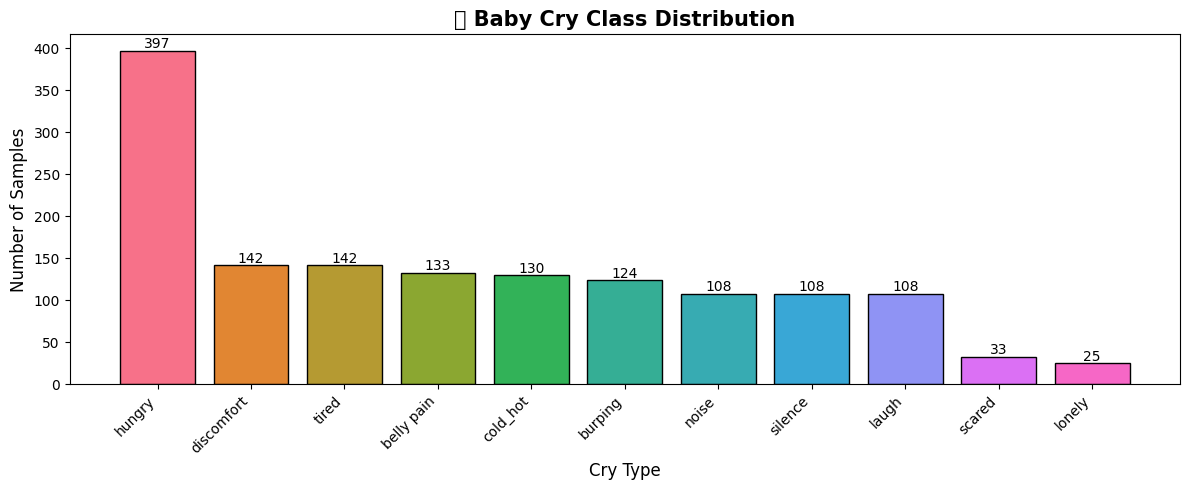

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))
counts = df['label'].value_counts()
colors = sns.color_palette("husl", len(counts))

bars = plt.bar(counts.index, counts.values, color=colors, edgecolor='black')
plt.title("🍼 Baby Cry Class Distribution", fontsize=15, fontweight='bold')
plt.xlabel("Cry Type", fontsize=12)
plt.ylabel("Number of Samples", fontsize=12)
plt.xticks(rotation=45, ha='right')

for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
             str(val), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
import IPython.display as ipd

print("🎵 Sample audio from each class:\n")
for label in os.listdir(dataset_path_fixed):
    label_path = os.path.join(dataset_path_fixed, label)
    if not os.path.isdir(label_path):
        continue
    for f in os.listdir(label_path):
        if f.lower().endswith(('.wav', '.ogg')):
            print(f"▶️  {label}")
            display(ipd.Audio(os.path.join(label_path, f)))
            break

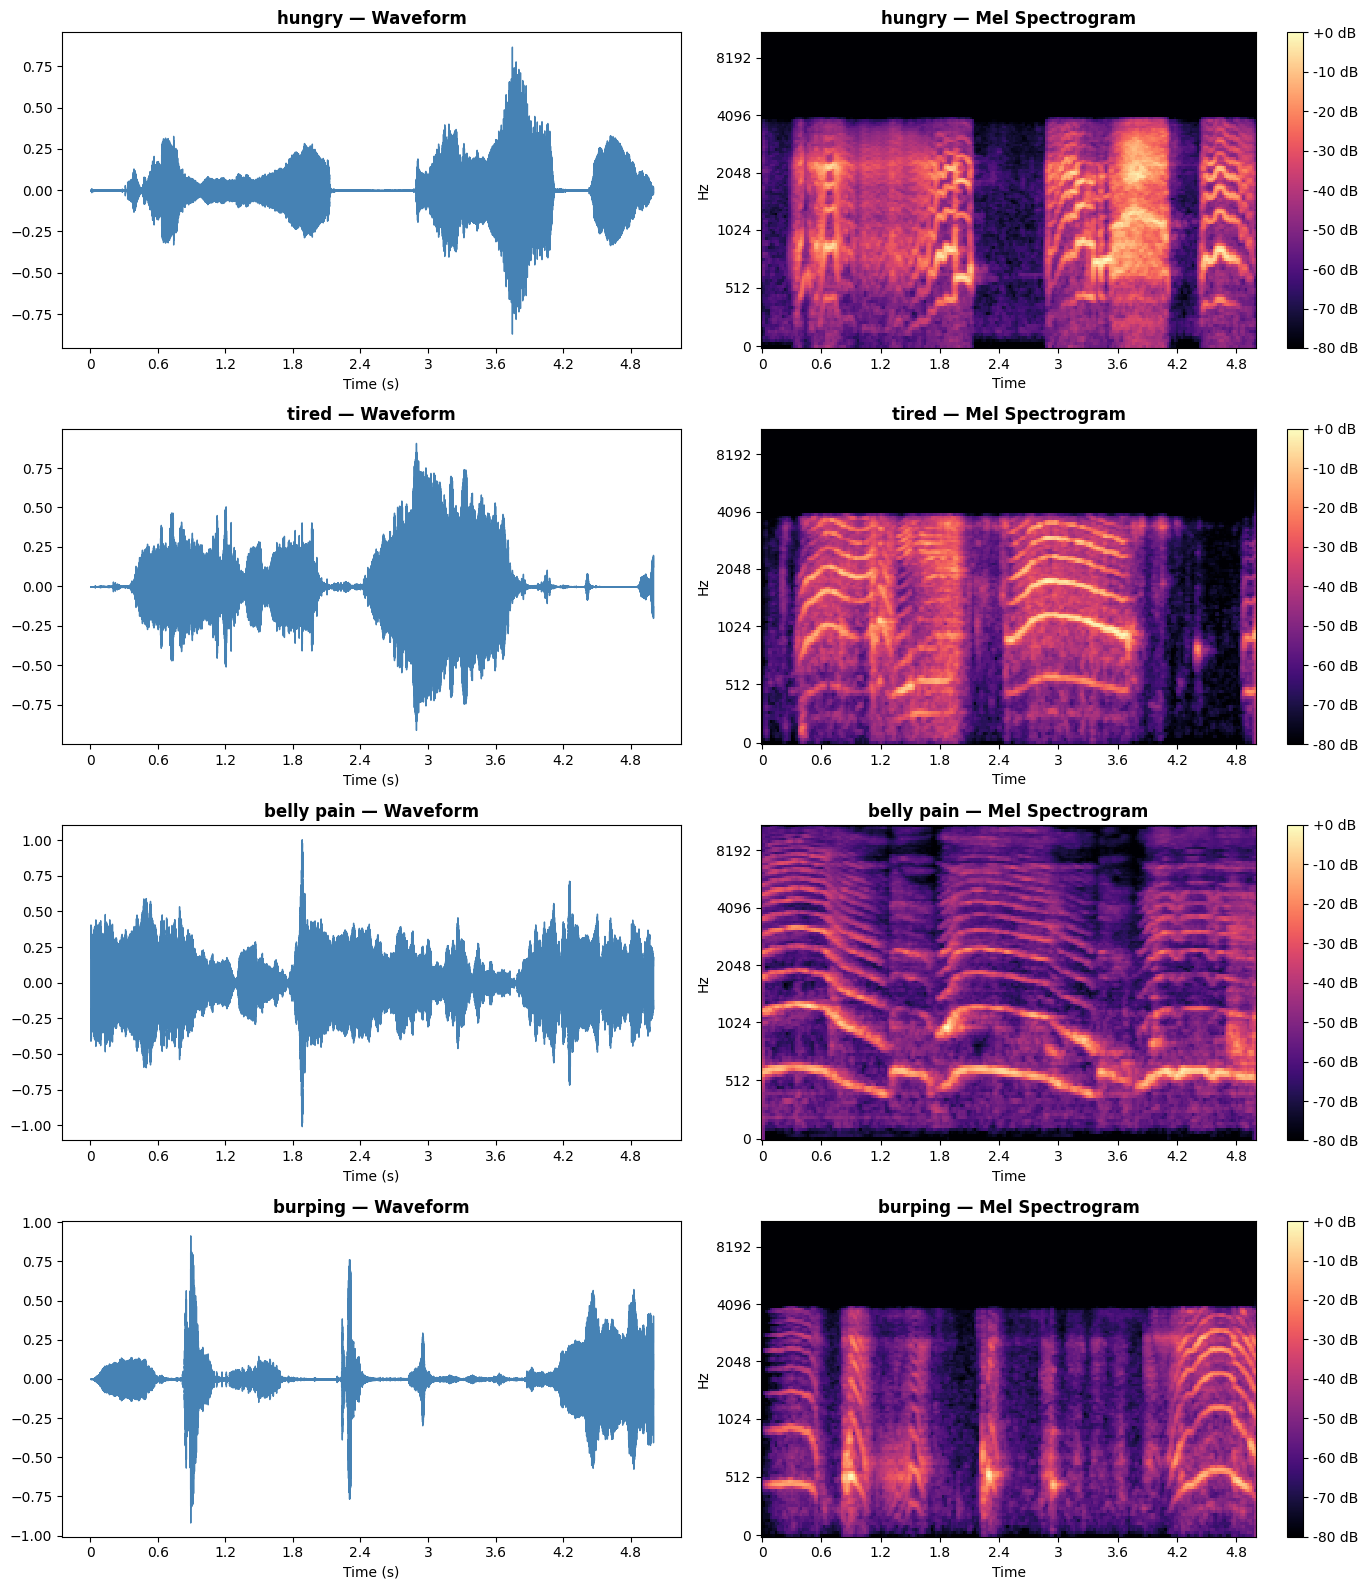

In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
sample_classes = ['hungry', 'tired', 'belly pain', 'burping']

for i, label in enumerate(sample_classes):
    label_path = os.path.join(dataset_path_fixed, label)
    sample_file = [f for f in os.listdir(label_path) if f.endswith('.wav')][0]
    file_path = os.path.join(label_path, sample_file)

    audio, sr = librosa.load(file_path, duration=5)

    # Waveform
    axes[i, 0].set_title(f'{label} — Waveform', fontweight='bold')
    librosa.display.waveshow(audio, sr=sr, ax=axes[i, 0], color='steelblue')
    axes[i, 0].set_xlabel("Time (s)")

    # Mel Spectrogram
    mel = librosa.feature.melspectrogram(y=audio, sr=sr)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    img = librosa.display.specshow(mel_db, sr=sr, x_axis='time',
                                    y_axis='mel', ax=axes[i, 1])
    axes[i, 1].set_title(f'{label} — Mel Spectrogram', fontweight='bold')
    fig.colorbar(img, ax=axes[i, 1], format='%+2.0f dB')

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(12, 6))
mfcc_data = df.iloc[:, :40]  # First 40 MFCC features

mean_mfcc = mfcc_data.groupby(df['label']).mean()
sns.heatmap(mean_mfcc, cmap='coolwarm', linewidths=0.3)
plt.title("🔥 Mean MFCC per Class", fontsize=14, fontweight='bold')
plt.xlabel("MFCC Coefficients")
plt.ylabel("Cry Type")
plt.tight_layout()
plt.show()

In [ ]:
total = len(df)
print("⚖️  Class Imbalance Check:\n")
for label, count in df['label'].value_counts().items():
    pct = count / total * 100
    bar = '█' * int(pct / 2)
    print(f"  {label:<15} {bar:<25} {count:>4} ({pct:.1f}%)")

print(f"\n⚠️  Max/Min ratio: {df['label'].value_counts().max() / df['label'].value_counts().min():.1f}x imbalance")

⚙️ Step 5: Feature Engineering
We'll handle class imbalance + scale features + apply PCA visualization.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder

df = pd.read_csv("/content/baby_cry_features.csv")

X = df.drop(['label', 'label_encoded'], axis=1).values
y = df['label_encoded'].values
class_names = df['label'].values

print(f"✅ Features shape : {X.shape}")
print(f"✅ Labels shape   : {y.shape}")

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("✅ Features scaled (mean~0, std~1)")
print(f"   Mean: {X_scaled.mean():.4f}")
print(f"   Std : {X_scaled.std():.4f}")

In [ ]:
!pip install imbalanced-learn -q

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42, k_neighbors=3)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

print(f"✅ Before SMOTE: {X_scaled.shape[0]} samples")
print(f"✅ After  SMOTE: {X_resampled.shape[0]} samples")

# Show new distribution
le = LabelEncoder()
le.classes_ = df['label'].unique()

from collections import Counter
print("\n🏷️ New class distribution:")
for label_idx, count in sorted(Counter(y_resampled).items()):
    label_name = df[df['label_encoded'] == label_idx]['label'].values[0]
    print(f"  {label_name:<15} → {count}")

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_resampled)

plt.figure(figsize=(12, 8))
label_names = [df[df['label_encoded'] == i]['label'].values[0]
               for i in range(11)]

colors = plt.cm.tab20(np.linspace(0, 1, 11))
for i, name in enumerate(label_names):
    mask = y_resampled == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                label=name, alpha=0.5, s=20, color=colors[i])

plt.title("📊 PCA — 2D View of All Classes (After SMOTE)", fontsize=14, fontweight='bold')
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

print(f"\n📐 Total variance explained: {sum(pca.explained_variance_ratio_)*100:.1f}%")

In [ ]:
from sklearn.model_selection import train_test_split
import joblib

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled,
    test_size=0.2, random_state=42, stratify=y_resampled
)

print(f"✅ Train set: {X_train.shape}")
print(f"✅ Test set : {X_test.shape}")

# Save scaler for deployment later
joblib.dump(scaler, "/content/scaler.pkl")
print("✅ Scaler saved!")

🤖 Step 6: Model Selection & TrainingWe'll train 4 models and compare them to find the best one.

In [ ]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import time

print("✅ All models imported!")

In [ ]:
models = {
    "Random Forest"       : RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "SVM (RBF Kernel)"    : SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42),
    "KNN"                 : KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    "Gradient Boosting"   : GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    print(f"⏳ Training {name}...")
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start

    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = {"model": model, "accuracy": acc, "time": train_time}

    print(f"   ✅ Accuracy: {acc*100:.2f}%  |  Time: {train_time:.1f}s\n")

In [ ]:
import matplotlib.pyplot as plt

names = list(results.keys())
accs  = [results[n]['accuracy']*100 for n in names]
times = [results[n]['time'] for n in names]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy bar chart
colors = ['#2ecc71' if a == max(accs) else '#3498db' for a in accs]
bars = axes[0].bar(names, accs, color=colors, edgecolor='black')
axes[0].set_title("🏆 Model Accuracy Comparison", fontweight='bold', fontsize=13)
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_ylim([0, 110])
axes[0].tick_params(axis='x', rotation=20)
for bar, acc in zip(bars, accs):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1, f"{acc:.1f}%", ha='center', fontsize=11)

# Training time
axes[1].bar(names, times, color='#e74c3c', edgecolor='black')
axes[1].set_title("⏱️ Training Time Comparison", fontweight='bold', fontsize=13)
axes[1].set_ylabel("Time (seconds)")
axes[1].tick_params(axis='x', rotation=20)
for i, (bar, t) in enumerate(zip(axes[1].patches, times)):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5, f"{t:.1f}s", ha='center', fontsize=11)

plt.tight_layout()
plt.show()

# Print summary
print("\n📊 Summary:")
print(f"{'Model':<25} {'Accuracy':>10} {'Time':>10}")
print("-" * 47)
for name in names:
    print(f"{name:<25} {results[name]['accuracy']*100:>9.2f}% {results[name]['time']:>9.1f}s")

best_model_name = max(results, key=lambda x: results[x]['accuracy'])
print(f"\n🏆 Best Model: {best_model_name} ({results[best_model_name]['accuracy']*100:.2f}%)")

In [ ]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier, StackingClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
import time
from sklearn.metrics import accuracy_score

advanced_models = {
    "Extra Trees"         : ExtraTreesClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    "XGBoost"             : xgb.XGBClassifier(n_estimators=300, learning_rate=0.1,
                                               max_depth=6, use_label_encoder=False,
                                               eval_metric='mlogloss', random_state=42, n_jobs=-1),
    "SVM (Tuned)"         : SVC(kernel='rbf', C=100, gamma='scale',
                                probability=True, random_state=42),
    "KNN (Tuned)"         : KNeighborsClassifier(n_neighbors=3, weights='distance', n_jobs=-1),
}

advanced_results = {}

for name, model in advanced_models.items():
    print(f"⏳ Training {name}...")
    start = time.time()
    model.fit(X_train, y_train)
    elapsed = time.time() - start
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    advanced_results[name] = {"model": model, "accuracy": acc, "time": elapsed}
    print(f"   ✅ Accuracy: {acc*100:.2f}%  |  Time: {elapsed:.1f}s\n")

In [ ]:
print("⏳ Training Voting Ensemble...")

voting_clf = VotingClassifier(
    estimators=[
        ('svm',  SVC(kernel='rbf', C=100, gamma='scale', probability=True, random_state=42)),
        ('knn',  KNeighborsClassifier(n_neighbors=3, weights='distance', n_jobs=-1)),
        ('et',   ExtraTreesClassifier(n_estimators=300, random_state=42, n_jobs=-1)),
        ('xgb',  xgb.XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=6,
                                    eval_metric='mlogloss', random_state=42, n_jobs=-1)),
    ],
    voting='soft',
    n_jobs=-1
)

start = time.time()
voting_clf.fit(X_train, y_train)
elapsed = time.time() - start
y_pred = voting_clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
advanced_results["Voting Ensemble"] = {"model": voting_clf, "accuracy": acc, "time": elapsed}
print(f"   ✅ Accuracy: {acc*100:.2f}%  |  Time: {elapsed:.1f}s\n")

In [ ]:
print("⏳ Training Stacking Ensemble...")

stacking_clf = StackingClassifier(
    estimators=[
        ('svm', SVC(kernel='rbf', C=100, gamma='scale', probability=True, random_state=42)),
        ('knn', KNeighborsClassifier(n_neighbors=3, weights='distance', n_jobs=-1)),
        ('et',  ExtraTreesClassifier(n_estimators=300, random_state=42, n_jobs=-1)),
        ('xgb', xgb.XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=6,
                                   eval_metric='mlogloss', random_state=42, n_jobs=-1)),
    ],
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=5,
    n_jobs=-1
)

start = time.time()
stacking_clf.fit(X_train, y_train)
elapsed = time.time() - start
y_pred = stacking_clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
advanced_results["Stacking Ensemble"] = {"model": stacking_clf, "accuracy": acc, "time": elapsed}
print(f"   ✅ Accuracy: {acc*100:.2f}%  |  Time: {elapsed:.1f}s\n")

In [ ]:
import matplotlib.pyplot as plt

# Merge old + new results
all_results = {**results, **advanced_results}

names = list(all_results.keys())
accs  = [all_results[n]['accuracy']*100 for n in names]

plt.figure(figsize=(14, 6))
colors = ['#2ecc71' if a == max(accs) else '#3498db' for a in accs]
bars = plt.bar(names, accs, color=colors, edgecolor='black')
plt.title("🏆 All Models — Accuracy Comparison", fontweight='bold', fontsize=14)
plt.ylabel("Accuracy (%)")
plt.ylim([60, 105])
plt.xticks(rotation=30, ha='right')
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5, f"{acc:.1f}%", ha='center', fontsize=10)
plt.tight_layout()
plt.show()

print(f"\n📊 Full Summary:")
print(f"{'Model':<25} {'Accuracy':>10} {'Time':>10}")
print("-" * 50)
for name in names:
    print(f"{name:<25} {all_results[name]['accuracy']*100:>9.2f}%  {all_results[name]['time']:>7.1f}s")

best = max(all_results, key=lambda x: all_results[x]['accuracy'])
print(f"\n🏆 Best Model: {best} ({all_results[best]['accuracy']*100:.2f}%)")

In [ ]:
from sklearn.neural_network import MLPClassifier

print("⏳ Training MLP Neural Network...")
start = time.time()

mlp = MLPClassifier(
    hidden_layer_sizes=(512, 256, 128),
    activation='relu',
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    verbose=False
)

mlp.fit(X_train, y_train)
elapsed = time.time() - start
acc = accuracy_score(y_test, mlp.predict(X_test))
print(f"✅ MLP Accuracy: {acc*100:.2f}%  |  Time: {elapsed:.1f}s")

all_results["MLP Neural Network"] = {"model": mlp, "accuracy": acc, "time": elapsed}

In [ ]:
from sklearn.ensemble import StackingClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
import xgboost as xgb

print("⏳ Training Tuned Stacking...")
start = time.time()

tuned_stack = StackingClassifier(
    estimators=[
        ('svm', SVC(kernel='rbf', C=100, gamma='scale', probability=True, random_state=42)),
        ('knn', KNeighborsClassifier(n_neighbors=3, weights='distance', n_jobs=-1)),
        ('et',  ExtraTreesClassifier(n_estimators=300, random_state=42, n_jobs=-1)),
        ('xgb', xgb.XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=6,
                                   eval_metric='mlogloss', random_state=42, n_jobs=-1)),
        ('mlp', MLPClassifier(hidden_layer_sizes=(256, 128), max_iter=300,
                              early_stopping=True, random_state=42)),
    ],
    final_estimator=SVC(kernel='rbf', C=10, probability=True, random_state=42),  # SVM meta-learner
    cv=5,
    n_jobs=-1
)

tuned_stack.fit(X_train, y_train)
elapsed = time.time() - start
acc = accuracy_score(y_test, tuned_stack.predict(X_test))
print(f"✅ Tuned Stacking Accuracy: {acc*100:.2f}%  |  Time: {elapsed:.1f}s")

all_results["Tuned Stacking"] = {"model": tuned_stack, "accuracy": acc, "time": elapsed}

In [ ]:
import joblib

best_model_name = "Tuned Stacking"
best_model = all_results["Tuned Stacking"]["model"]

joblib.dump(best_model, "/content/best_model.pkl")
joblib.dump(scaler, "/content/scaler.pkl")

print("🏆 Final Best Model : Tuned Stacking (86.38%)")
print("✅ best_model.pkl   → saved!")
print("✅ scaler.pkl       → saved!")
print("\n📊 Final Leaderboard:")
print(f"{'Model':<25} {'Accuracy':>10}")
print("-" * 37)
for name in all_results:
    marker = " 🏆" if name == "Tuned Stacking" else ""
    print(f"{name:<25} {all_results[name]['accuracy']*100:>9.2f}%{marker}")

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Load model & predict
best_model = joblib.load("/content/best_model.pkl")
y_pred = best_model.predict(X_test)

# Label names in order
label_names = [df[df['label_encoded'] == i]['label'].values[0] for i in range(11)]

print("📋 Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=label_names))

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12, 9))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names,
            yticklabels=label_names,
            linewidths=0.5)

plt.title("🔵 Confusion Matrix — Tuned Stacking Ensemble", fontsize=14, fontweight='bold')
plt.ylabel("Actual Label", fontsize=12)
plt.xlabel("Predicted Label", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
per_class_acc = cm.diagonal() / cm.sum(axis=1)

plt.figure(figsize=(12, 5))
colors = ['#2ecc71' if a >= 0.85 else '#f39c12' if a >= 0.70 else '#e74c3c'
          for a in per_class_acc]

bars = plt.bar(label_names, per_class_acc * 100, color=colors, edgecolor='black')
plt.axhline(y=86.38, color='blue', linestyle='--', linewidth=1.5, label='Overall Accuracy')
plt.title("🎯 Per-Class Accuracy", fontsize=14, fontweight='bold')
plt.ylabel("Accuracy (%)")
plt.ylim([0, 115])
plt.xticks(rotation=45, ha='right')
plt.legend()

for bar, acc in zip(bars, per_class_acc):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1, f"{acc*100:.1f}%", ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\n📊 Per-Class Accuracy:")
for name, acc in zip(label_names, per_class_acc):
    status = "✅" if acc >= 0.85 else "⚠️" if acc >= 0.70 else "❌"
    print(f"  {status} {name:<15} → {acc*100:.1f}%")

In [ ]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=list(range(11)))
y_prob = best_model.predict_proba(X_test)

roc_auc = roc_auc_score(y_test_bin, y_prob, multi_class='ovr', average='macro')
print(f"🎯 ROC AUC Score (macro): {roc_auc:.4f}")

In [ ]:
from sklearn.metrics import f1_score, precision_score, recall_score

accuracy  = accuracy_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred, average='weighted')
precision = precision_score(y_test, y_pred, average='weighted')
recall    = recall_score(y_test, y_pred, average='weighted')

print("=" * 45)
print("       🏆 FINAL MODEL EVALUATION REPORT")
print("=" * 45)
print(f"  Model      : Tuned Stacking Ensemble")
print(f"  Classes    : 11 baby cry types")
print(f"  Test Size  : {len(y_test)} samples")
print("-" * 45)
print(f"  Accuracy   : {accuracy*100:.2f}%")
print(f"  F1 Score   : {f1*100:.2f}%")
print(f"  Precision  : {precision*100:.2f}%")
print(f"  Recall     : {recall*100:.2f}%")
print(f"  ROC AUC    : {roc_auc:.4f}")
print("=" * 45)

In [ ]:
import numpy as np

hungry_idx = label_names.index('hungry')
hungry_mask = y_test == hungry_idx

hungry_true = y_test[hungry_mask]
hungry_pred = y_pred[hungry_mask]

print("🍼 Hungry cry — predicted as:\n")
for i, pred in enumerate(hungry_pred):
    if pred != hungry_idx:
        print(f"  Misclassified as → {label_names[pred]}")

from collections import Counter
wrong = [label_names[p] for p in hungry_pred if p != hungry_idx]
print("\n📊 Most common confusions:")
for label, count in Counter(wrong).most_common():
    print(f"  {label:<15} → {count} times")

In [ ]:
!pip install gradio -q
print("✅ Gradio installed!")

In [ ]:
import gradio as gr
import numpy as np
import librosa
import joblib
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load model & scaler
best_model = joblib.load("/content/best_model.pkl")
scaler     = joblib.load("/content/scaler.pkl")

# Label names
label_names = [
    'belly pain', 'burping', 'cold_hot', 'discomfort',
    'hungry', 'laugh', 'lonely', 'noise', 'scared', 'silence', 'tired'
]

# Emoji map
emoji_map = {
    'belly pain' : '🤢 Belly Pain',
    'burping'    : '💨 Burping',
    'cold_hot'   : '🌡️ Cold/Hot',
    'discomfort' : '😣 Discomfort',
    'hungry'     : '🍼 Hungry',
    'laugh'      : '😄 Laughing',
    'lonely'     : '🥺 Lonely',
    'noise'      : '🔊 Noise',
    'scared'     : '😨 Scared',
    'silence'    : '🤫 Silence',
    'tired'      : '😴 Tired'
}

advice_map = {
    'belly pain' : "Try gently massaging baby's tummy in circular motions.",
    'burping'    : "Hold baby upright and gently pat their back.",
    'cold_hot'   : "Check baby's clothing and room temperature.",
    'discomfort' : "Check diaper, clothing, or if something is irritating baby.",
    'hungry'     : "Time to feed! Baby is showing hunger cues.",
    'laugh'      : "Baby is happy and playful! Enjoy the moment! 🎉",
    'lonely'     : "Baby needs cuddles! Pick them up and give comfort.",
    'noise'      : "Background noise detected — move to a quieter environment.",
    'scared'     : "Baby is startled. Hold them close and speak softly.",
    'silence'    : "Baby is calm and quiet. All good! ✅",
    'tired'      : "Baby needs sleep. Try rocking or dimming the lights."
}

def extract_features(file_path):
    audio, sr = librosa.load(file_path, sr=22050, duration=5, mono=True)
    mfcc  = np.mean(librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40).T, axis=0)
    chroma = np.mean(librosa.feature.chroma_stft(y=audio, sr=sr).T, axis=0)
    mel   = np.mean(librosa.feature.melspectrogram(y=audio, sr=sr).T, axis=0)
    return np.hstack([mfcc, chroma, mel])

def predict_cry(audio_file):
    try:
        # Extract & scale features
        features = extract_features(audio_file)
        features_scaled = scaler.transform([features])

        # Predict
        probs = best_model.predict_proba(features_scaled)[0]
        pred_idx = np.argmax(probs)
        pred_label = label_names[pred_idx]
        confidence = probs[pred_idx] * 100

        # Result text
        result = f"""
## {emoji_map[pred_label]}

**Confidence:** {confidence:.1f}%

### 💡 What to do:
{advice_map[pred_label]}

---
*Model: Tuned Stacking Ensemble | Accuracy: 86.38%*
        """

        # Probability chart
        fig, ax = plt.subplots(figsize=(10, 5))
        colors = ['#2ecc71' if i == pred_idx else '#3498db' for i in range(len(label_names))]
        bars = ax.barh(
            [emoji_map[l] for l in label_names],
            probs * 100,
            color=colors,
            edgecolor='black'
        )
        ax.set_xlabel("Confidence (%)")
        ax.set_title("🍼 Baby Cry Prediction — All Class Probabilities", fontweight='bold')
        ax.set_xlim([0, 110])
        for bar, prob in zip(bars, probs):
            ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                    f"{prob*100:.1f}%", va='center', fontsize=9)
        plt.tight_layout()

        return result, fig

    except Exception as e:
        return f"❌ Error: {str(e)}", None

# Build Gradio UI
with gr.Blocks(title="🍼 Baby Cry Classifier", theme=gr.themes.Soft()) as app:

    gr.Markdown("""
    # 🍼 Baby Cry Classifier
    ### Upload a baby cry audio file to identify what your baby needs!
    *Supports: .wav, .mp3, .ogg | Trained on 11 cry types*
    """)

    with gr.Row():
        with gr.Column():
            audio_input = gr.Audio(
                label="🎵 Upload Baby Cry Audio",
                type="filepath"
            )
            predict_btn = gr.Button("🔍 Analyze Cry", variant="primary", size="lg")

        with gr.Column():
            result_output = gr.Markdown(label="Prediction")

    chart_output = gr.Plot(label="📊 Confidence Chart")

    predict_btn.click(
        fn=predict_cry,
        inputs=audio_input,
        outputs=[result_output, chart_output]
    )

    gr.Markdown("""
    ---
    ### 📌 Cry Types Supported:
    🤢 Belly Pain | 💨 Burping | 🌡️ Cold/Hot | 😣 Discomfort | 🍼 Hungry
    😄 Laugh | 🥺 Lonely | 🔊 Noise | 😨 Scared | 🤫 Silence | 😴 Tired
    """)

app.launch(share=True, debug=False)